In [1]:
# imports

import numpy as np

from skfp.datasets.moleculenet import load_bace
from skfp.fingerprints import ECFPFingerprint
from skfp.model_selection import scaffold_train_test_split
from skfp.preprocessing import MolFromSmilesTransformer

from sklearn import metrics

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import LinearSVC

c:\Users\corah\OneDrive - Universität des Saarlandes\_MA\code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# BEDROC score implementation from scikit-chem (https://scikit-chem.readthedocs.io/en/latest/_modules/skchem/metrics.html)

def bedroc_score(y_true, y_pred, decreasing=True, alpha=20.0):

    """BEDROC metric implemented according to Truchon and Bayley.

    The Boltzmann Enhanced Descrimination of the Receiver Operator
    Characteristic (BEDROC) score is a modification of the Receiver Operator
    Characteristic (ROC) score that allows for a factor of *early recognition*.

    References:
        The original paper by Truchon et al. is located at `10.1021/ci600426e
        <http://dx.doi.org/10.1021/ci600426e>`_.

    Args:
        y_true (array_like):
            Binary class labels. 1 for positive class, 0 otherwise.
        y_pred (array_like):
            Prediction values.
        decreasing (bool):
            True if high values of ``y_pred`` correlates to positive class.
        alpha (float):
            Early recognition parameter.

    Returns:
        float:
            Value in interval [0, 1] indicating degree to which the predictive
            technique employed detects (early) the positive class.
     """

    assert len(y_true) == len(y_pred), \
        'The number of scores must be equal to the number of labels'

    big_n = len(y_true)
    n = sum(y_true == 1)

    if decreasing:
        order = np.argsort(-y_pred)
    else:
        order = np.argsort(y_pred)

    m_rank = (y_true[order] == 1).nonzero()[0]

    s = np.sum(np.exp(-alpha * m_rank / big_n))

    r_a = n / big_n

    rand_sum = r_a * (1 - np.exp(-alpha))/(np.exp(alpha/big_n) - 1)

    fac = r_a * np.sinh(alpha / 2) / (np.cosh(alpha / 2) -
                                      np.cosh(alpha/2 - alpha * r_a))

    cte = 1 / (1 - np.exp(alpha * (1 - r_a)))

    return s * fac / rand_sum + cte

In [3]:
# evaluate model

def evaluate(y_true, y_pred_probs, y_pred_classes) -> None:
    # display ROC curve
    display = metrics.RocCurveDisplay.from_predictions(
        y_true, 
        y_pred_probs,
        curve_kwargs = dict(color = "darkred"),
        plot_chance_level = True,
        despine = True
    )

    _ = display.ax_.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title = "Receiver-Operating-Curve"
    )

    p = metrics.precision_score(y_true, y_pred_classes)
    print(f"PRECISION: {p:.2%}")

    r = metrics.recall_score(y_true, y_pred_classes)
    print(f"RECALL: {r:.2%}")

    f1 = metrics.f1_score(y_true, y_pred_classes)
    print(f"F1: {f1:.2%}")

    auroc = metrics.roc_auc_score(y_true, y_pred_probs)
    print(f"AUROC: {auroc:.2%}")

    precision, recall, _ = metrics.precision_recall_curve(y_true, y_pred_probs)
    auprc = metrics.auc(recall, precision)
    print(f"AUPRC: {auprc:.2%}")

    bedroc = bedroc_score(y_true, y_pred_probs, alpha = 20)   # what does alpha mean here? what is early recognition?
    print(f"BEDROC: {bedroc:.2%}")

    # PPV & NPV (as in Deng et al., https://github.com/dengjianyuan/Respite_MPP/blob/main/notebooks/Performance_Metrics_Calculation.ipynb)
    fpr, tpr, proba = metrics.roc_curve(y_true, y_pred_probs)
    # calculate the optimal probability cutoff using Youden's J statistic with equal weight to FP and FN
    optimal_proba_cutoff = sorted(list(zip(np.abs(tpr - fpr), proba)),\
                                    key=lambda i: i[0], reverse=True)[0][1]
    # get hard_preds
    hard_preds = [1 if p > optimal_proba_cutoff else 0 for p in y_pred_probs]
    # calculate precision based on hard_preds - pos_label as 1
    ppv = metrics.precision_score(y_true, hard_preds, pos_label=1)
    # calculate precision based on hard_preds - pos_label as 0
    npv = metrics.precision_score(y_true, hard_preds, pos_label=0)
    print(f"PPV: {ppv:.2%}")
    print(f"NPV: {npv:.2%}")


In [4]:
# hyperparameters
TEST_SIZE = 0.2
RANDOM_STATE = 27

In [5]:
# load data (BACE dataset from MoleculeNet)
smiles_list, y = load_bace()

# convert to RDKit Mol objects
mol_from_smiles = MolFromSmilesTransformer()
mols = mol_from_smiles.transform(smiles_list)

# split based on scaffolds
mols_train, mols_test, y_train, y_test = scaffold_train_test_split(mols, y, test_size = TEST_SIZE)

# get ECFP fingerprints for Mol objects
ecfp_fp = ECFPFingerprint()
X_train = ecfp_fp.transform(mols_train)
X_test = ecfp_fp.transform(mols_test)

In [6]:
# class imbalanc due to scaffold splitting?

print(f"#positive in train: {sum(y_train)}/{len(y_train)} = {sum(y_train)/len(y_train):.2%}")
print(f"#positive in test: {sum(y_test)}/{len(y_test)} = {sum(y_test)/len(y_test):.2%}")

#positive in train: 515/1210 = 42.56%
#positive in test: 176/303 = 58.09%


PRECISION: 80.58%
RECALL: 63.64%
F1: 71.11%
AUROC: 77.81%
AUPRC: 81.25%
BEDROC: 99.30%
PPV: 75.79%
NPV: 71.68%


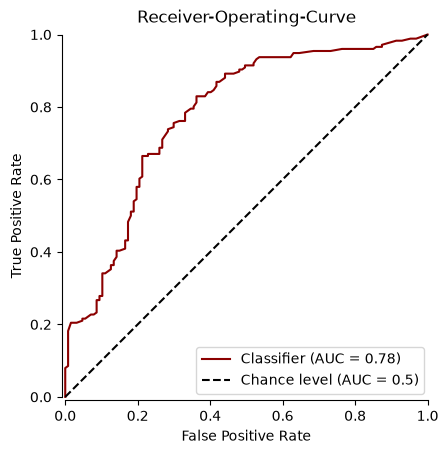

In [7]:
# Random Forest Classifier

# instantiate and train
clf_rf = RandomForestClassifier(random_state = RANDOM_STATE)
clf_rf.fit(X_train, y_train)

# predict
y_pred_rf = clf_rf.predict_proba(X_test)[:, 1]
y_pred_classes_rf = clf_rf.predict(X_test)

# evaluate
evaluate(y_test, y_pred_rf, y_pred_classes_rf)

[0]	validation_0-logloss:0.69016
[1]	validation_0-logloss:0.64746
[2]	validation_0-logloss:0.64191
[3]	validation_0-logloss:0.63495
[4]	validation_0-logloss:0.64016
[5]	validation_0-logloss:0.63655
PRECISION: 82.14%
RECALL: 52.27%
F1: 63.89%
AUROC: 76.01%
AUPRC: 80.39%
BEDROC: 96.76%
PPV: 76.79%
NPV: 65.19%


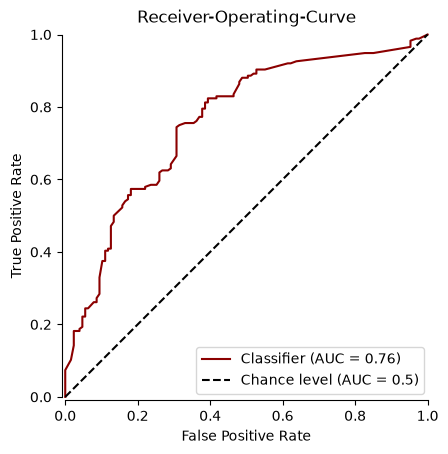

In [8]:
# XGBoost

# instantiate and train
clf_xgb = xgb.XGBClassifier(tree_method = "hist", early_stopping_rounds = 2)
clf_xgb.fit(X_train, y_train, eval_set = [(X_test, y_test)])

# predict
y_pred_xgb = clf_xgb.predict_proba(X_test)[:, 1]
y_pred_classes_xgb = clf_xgb.predict(X_test)

# evaluate
evaluate(y_test, y_pred_xgb, y_pred_classes_xgb)

PRECISION: 76.35%
RECALL: 64.20%
F1: 69.75%
AUROC: 68.32%
AUPRC: 80.67%
BEDROC: 68.23%
PPV: 0.00%
NPV: 41.91%


c:\Users\corah\OneDrive - Universität des Saarlandes\_MA\code\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


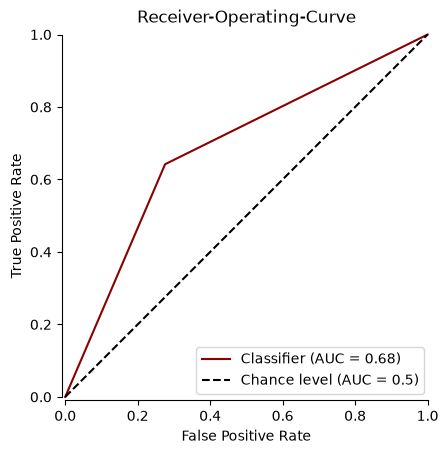

In [9]:
# Support Vector Machine

# instantiate and train
clf_svm = LinearSVC(random_state = RANDOM_STATE, tol = 1e-5, max_iter = 20000)
clf_svm.fit(X_train, y_train)

# predict
y_pred_classes_svm = clf_svm.predict(X_test)

# evaluate
evaluate(y_test, y_pred_classes_svm, y_pred_classes_svm)